# Lobster Plots (Refactored)

This notebook computes and visualizes the *effective Majorana mass* $|m_{\beta\beta}|$ as a function of the lightest neutrino mass $m_l$, including statistical uncertainty from the global neutrino oscillation fit. All reusable physics functions are factored into `lobster_module.py`; this notebook handles orchestration and visualization.

---

## Physics Background

### PMNS Mixing Matrix

The Pontecorvo–Maki–Nakagawa–Sakata (PMNS) matrix $U$ relates the flavor eigenstates $(\nu_e, \nu_\mu, \nu_\tau)$ to the mass eigenstates $(\nu_1, \nu_2, \nu_3)$:

$$U = \begin{pmatrix} c_{12}c_{13} & s_{12}c_{13} & s_{13}e^{-i\delta} \\ -s_{12}c_{23} - c_{12}s_{23}s_{13}e^{i\delta} & c_{12}c_{23} - s_{12}s_{23}s_{13}e^{i\delta} & s_{23}c_{13} \\ s_{12}s_{23} - c_{12}c_{23}s_{13}e^{i\delta} & -c_{12}s_{23} - s_{12}c_{23}s_{13}e^{i\delta} & c_{23}c_{13} \end{pmatrix}$$

where $c_{ij} \equiv \cos\theta_{ij}$, $s_{ij} \equiv \sin\theta_{ij}$, and $\delta$ is the Dirac CP-violating phase.

### Majorana Phase Matrix

If neutrinos are Majorana particles, two additional CP-violating phases $\alpha_1$ and $\alpha_2$ enter through a diagonal phase matrix appended on the right:

$$U_\text{PMNS}^{\,\text{Majorana}} = U \cdot P, \qquad P = \mathrm{diag}\!\left(1,\; e^{i\alpha_1/2},\; e^{i\alpha_2/2}\right)$$

These Majorana phases are physical but entirely invisible in neutrino oscillation experiments — they appear only in lepton-number-violating processes.

### Effective Majorana Mass

The rate of neutrinoless double-beta ($0\nu\beta\beta$) decay is proportional to $|m_{\beta\beta}|^2$, where the effective Majorana mass is

$$\boxed{|m_{\beta\beta}| = \left|\, |U_{e1}|^2\, m_1 \;+\; |U_{e2}|^2\, m_2\, e^{i\alpha_1} \;+\; |U_{e3}|^2\, m_3\, e^{i\alpha_2} \,\right|}$$

with the electron-row mixing elements

$$|U_{e1}|^2 = \cos^2\!\theta_{12}\cos^2\!\theta_{13}, \qquad |U_{e2}|^2 = \sin^2\!\theta_{12}\cos^2\!\theta_{13}, \qquad |U_{e3}|^2 = \sin^2\!\theta_{13}$$

The mass eigenvalues are related to the lightest mass $m_l$ and the measured splittings:

| Ordering | $m_1$ | $m_2$ | $m_3$ |
|---|---|---|---|
| **NO** ($m_1 < m_2 < m_3$) | $m_l$ | $\sqrt{m_1^2 + \Delta m^2_{21}}$ | $\sqrt{m_1^2 + |\Delta m^2_{31}|}$ |
| **IO** ($m_3 < m_1 < m_2$) | $\sqrt{m_3^2 + |\Delta m^2_{31}|}$ | $\sqrt{m_1^2 + \Delta m^2_{21}}$ | $m_l$ |

Because $\alpha_1, \alpha_2 \in [0, 2\pi)$ are unknown, $|m_{\beta\beta}|$ sweeps out a band for each value of $m_l$. This notebook maps that band by Monte Carlo sampling of both the oscillation parameters (within their $1\sigma$ experimental ranges) and the Majorana phases.

## 1. Imports

Standard scientific Python stack (`numpy`, `pandas`, `matplotlib`) plus `lobster_module`, which contains all reusable physics, sampling, and histogram utility functions.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import lobster_module as lm

## 2. Neutrino Oscillation Parameter Data

Two data sources provide the oscillation parameters used throughout:

- **`nu_global_fit_data.txt`** — a summary table of best-fit values and asymmetric $1\sigma$ errors from the NuFIT global analysis.
- **`ahep_globalfit_chi2/1-dim/*.dat`** — per-parameter $\Delta\chi^2$ profiles for both normal (NO) and inverted (IO) ordering, used to fit parabolas and extract precise $1\sigma$ error bounds.

The code builds `params_dict_NO` / `params_dict_IO`, simple `{name: best_fit}` dictionaries used throughout to evaluate $|m_{\beta\beta}|$, as well as `df_NO` / `df_IO` DataFrames that carry the full $1\sigma$ error information needed for Monte Carlo sampling.

In [2]:
nu_global_fit_data = lm.ingest_nu_global_fit_data("nu_global_fit_data.txt")
df_global_fit = pd.DataFrame(nu_global_fit_data["rows"])
df_global_fit.head()

,parameter,central,err_minus,err_plus,sigma2_range,sigma3_range
0,\Delta m^2_{21}: [10^{-5} eV^2],7.50,0.20,0.22,7.11–7.93,6.94–8.14
1,|\Delta m^2_{31}|: [10^{-3} eV^2] (NO),2.55,0.03,0.02,2.49–2.60,2.47–2.63
2,|\Delta m^2_{31}|: [10^{-3} eV^2] (IO),2.45,0.03,0.02,2.39–2.50,2.37–2.53
3,\sin^2\theta_{12} / 10^{-1},3.18,0.16,0.16,2.86–3.52,2.71–3.69
4,\sin^2\theta_{23} / 10^{-1} (NO),5.74,0.14,0.14,5.41–5.99,4.34–6.10


In [3]:
df_NO, df_IO = lm.build_globalfit_tables(data_path="./ahep_globalfit_chi2/1-dim/")
params_dict_NO = lm.params_dict_from_df(df_NO)
params_dict_IO = lm.params_dict_from_df(df_IO)

display(df_NO.head())
display(df_IO.head())

,Param,BestFit,ErrorMinus,ErrorPlus
0,del,1.096264,0.970361,1.222167
1,dm21,0.000075,0.000073,0.000077
2,dm31,0.002546,0.002520,0.002573
3,sq12,0.318467,0.302182,0.334752
4,sq13,0.022019,0.021339,0.022699


,Param,BestFit,ErrorMinus,ErrorPlus
0,del,1.566940,1.415725,1.718155
1,dm21,0.000075,0.000073,0.000077
2,dm31,0.002448,0.002420,0.002475
3,sq12,0.318467,0.302182,0.334752
4,sq13,0.022198,0.021522,0.022874


In [4]:
from IPython.display import Markdown

# Human-readable labels, display units, scale factor, and decimal places for each parameter.
param_display = {
    "dm21": (r"$\Delta m^2_{21}$",         r"$\times 10^{-5}\ \mathrm{eV}^2$", 1e5, 4),
    "dm31": (r"$\|\Delta m^2_{31}\|$",     r"$\times 10^{-3}\ \mathrm{eV}^2$", 1e3, 4),
    "sq12": (r"$\sin^2\!\theta_{12}$",      "",                                  1.0, 4),
    "sq13": (r"$\sin^2\!\theta_{13}$",      "",                                  1.0, 5),
    "sq23": (r"$\sin^2\!\theta_{23}$",      "",                                  1.0, 4),
    "del":  (r"$\delta_\mathrm{CP}$",       "rad",                               1.0, 3),
}

no = df_NO.set_index("Param")
io = df_IO.set_index("Param")

header = "| Parameter | Units | NO best fit | NO $-1\\sigma$ | NO $+1\\sigma$ | IO best fit | IO $-1\\sigma$ | IO $+1\\sigma$ |"
sep = "|:---|:---|---:|---:|---:|---:|---:|---:|"
rows = [header, sep]

for p, (label, unit, scale, dec) in param_display.items():
    if p not in no.index or p not in io.index:
        continue
    r_no, r_io = no.loc[p], io.loc[p]

    # ErrorMinus / ErrorPlus are absolute parameter values at the ±1σ chi² = 1 crossings.
    def fv(v):
        return f"{v * scale:.{dec}f}"

    rows.append(
        f"| {label} | {unit} "
        f"| {fv(r_no.BestFit)} | {fv(r_no.BestFit - r_no.ErrorMinus)} | {fv(r_no.ErrorPlus - r_no.BestFit)} "
        f"| {fv(r_io.BestFit)} | {fv(r_io.BestFit - r_io.ErrorMinus)} | {fv(r_io.ErrorPlus - r_io.BestFit)} |"
    )

# Escape literal pipes in the markdown table labels so Markdown doesn't split columns.
display(Markdown("**Oscillation parameter best fits with $1\\sigma$ uncertainties (from $\\Delta\\chi^2 = 1$ profiles)**\n\n" + "\n".join(rows)))

**Oscillation parameter best fits with $1\sigma$ uncertainties (from $\Delta\chi^2 = 1$ profiles)**

| Parameter | Units | NO best fit | NO $-1\sigma$ | NO $+1\sigma$ | IO best fit | IO $-1\sigma$ | IO $+1\sigma$ |
|:---|:---|---:|---:|---:|---:|---:|---:|
| $\Delta m^2_{21}$ | $\times 10^{-5}\ \mathrm{eV}^2$ | 7.5039 | 0.2117 | 0.2117 | 7.5039 | 0.2117 | 0.2117 |
| $\|\Delta m^2_{31}\|$ | $\times 10^{-3}\ \mathrm{eV}^2$ | 2.5464 | 0.0269 | 0.0269 | 2.4476 | 0.0278 | 0.0278 |
| $\sin^2\!\theta_{12}$ |  | 0.3185 | 0.0163 | 0.0163 | 0.3185 | 0.0163 | 0.0163 |
| $\sin^2\!\theta_{13}$ |  | 0.02202 | 0.00068 | 0.00068 | 0.02220 | 0.00068 | 0.00068 |
| $\sin^2\!\theta_{23}$ |  | 0.5731 | 0.0138 | 0.0138 | 0.5730 | 0.0134 | 0.0134 |
| $\delta_\mathrm{CP}$ | rad | 1.096 | 0.126 | 0.126 | 1.567 | 0.151 | 0.151 |

## 3. Best-Fit Lobster Plot (Single Phase)

A quick sanity-check: $|m_{\beta\beta}|(m_l)$ evaluated at best-fit oscillation parameters with Majorana phases fixed to zero. This traces the central value of the allowed band for each mass ordering and confirms the parameter ingestion is working correctly.

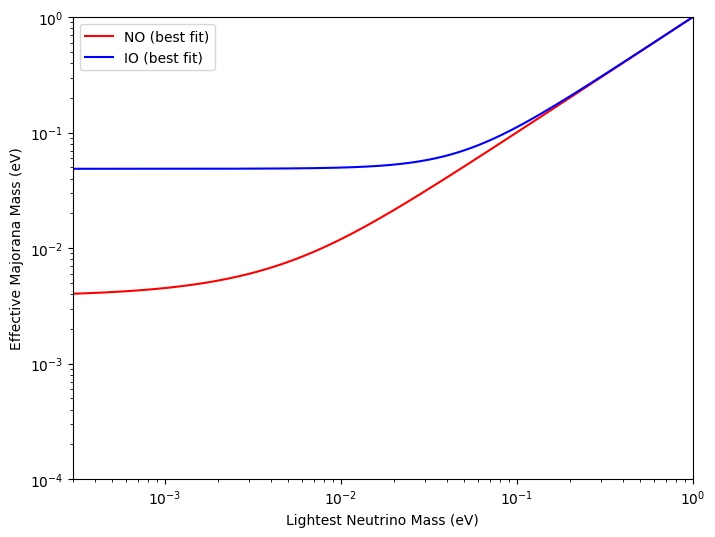

In [5]:
m_l = np.logspace(-4.0, 0.0, 300)
mbb_NO = lm.majorana_mass(params_dict_NO, ordering="NO", m_l=m_l)
mbb_IO = lm.majorana_mass(params_dict_IO, ordering="IO", m_l=m_l)

plt.figure(figsize=(8, 6))
plt.plot(m_l, mbb_NO, color="red", label="NO (best fit)")
plt.plot(m_l, mbb_IO, color="blue", label="IO (best fit)")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Lightest Neutrino Mass (eV)")
plt.ylabel("Effective Majorana Mass (eV)")
plt.xlim(3e-4, 1.0)
plt.ylim(1e-4, 1.0)
plt.legend()
plt.show()

## 4. Monte Carlo Sample Generation

To map the full probability density of $|m_{\beta\beta}|(m_l)$, oscillation parameters are drawn uniformly within their $1\sigma$ experimental ranges, and the Majorana phases are drawn uniformly over $[0, 2\pi)$. This is repeated for each point on a logarithmic $m_l$ grid.

The resulting $(m_l,\, m_{\beta\beta})$ point cloud is cached in `mbb_density_samples.pkl`. On subsequent runs, the cache is reloaded automatically to skip the expensive sampling step.

In [6]:
cache_path = "mbb_density_samples.pkl"
m_l_grid = np.logspace(-4.0, 0.0, 120)
n_samples_per_m = 500

if os.path.exists(cache_path):
    cache_payload = lm.load_sample_cache(cache_path)

    m_l_grid = cache_payload.get("m_l_grid", cache_payload.get("m_l_values", m_l_grid))
    m_NO_pts = cache_payload.get("m_NO_pts", cache_payload.get("m_NO"))
    mbb_NO_pts = cache_payload.get("mbb_NO_pts", cache_payload.get("mbb_NO"))
    m_IO_pts = cache_payload.get("m_IO_pts", cache_payload.get("m_IO"))
    mbb_IO_pts = cache_payload.get("mbb_IO_pts", cache_payload.get("mbb_IO"))

    # Backward compatibility for older cache payloads.
    if m_NO_pts is None or mbb_NO_pts is None:
        m_NO_pts = cache_payload.get("m_NO_samples", cache_payload.get("m_no"))
        mbb_NO_pts = cache_payload.get("mbb_NO_samples", cache_payload.get("mbb_no"))
    if m_IO_pts is None or mbb_IO_pts is None:
        m_IO_pts = cache_payload.get("m_IO_samples", cache_payload.get("m_io"))
        mbb_IO_pts = cache_payload.get("mbb_IO_samples", cache_payload.get("mbb_io"))

    if m_NO_pts is None or mbb_NO_pts is None or m_IO_pts is None or mbb_IO_pts is None:
        raise KeyError("Cache file exists but does not contain recognized sample keys.")

    cfg = cache_payload.get("config", {})
    if "m_grid" in cfg:
        m_l_grid = np.asarray(cfg["m_grid"])
else:
    rng = np.random.default_rng(7)
    m_NO_pts, mbb_NO_pts = lm.generate_mbb_density_samples(
        params_dict_NO,
        df_ref=df_NO,
        ordering="NO",
        m_l_grid=m_l_grid,
        n_samples_per_m=n_samples_per_m,
        rng=rng,
    )
    m_IO_pts, mbb_IO_pts = lm.generate_mbb_density_samples(
        params_dict_IO,
        df_ref=df_IO,
        ordering="IO",
        m_l_grid=m_l_grid,
        n_samples_per_m=n_samples_per_m,
        rng=rng,
    )

    lm.save_sample_cache(
        cache_path,
        {
            "m_l_grid": m_l_grid,
            "m_NO_pts": m_NO_pts,
            "mbb_NO_pts": mbb_NO_pts,
            "m_IO_pts": m_IO_pts,
            "mbb_IO_pts": mbb_IO_pts,
        },
    )

len(m_NO_pts), len(m_IO_pts)

(137500, 137500)

## 5. Histogram Setup and Plotting Helpers

The raw $(m_l,\, m_{\beta\beta})$ sample pairs are binned into a 2D histogram. The $x$-bins are constructed to align exactly with the sampled $m_l$ grid points (avoiding empty-column artifacts), and the $y$-bins span the full $m_{\beta\beta}$ range logarithmically.

This cell also defines:
- **Physical constants** and XLZD half-life assumptions for 80 t and 60 t exposures.
- `mbb_band_from_halflife` — converts a $(T_{1/2}^{\text{range}},\; \text{NME range})$ pair into an $m_{\beta\beta}$ band via $|m_{\beta\beta}| = (G g_A^4 |M_{0\nu}|^2 T_{1/2})^{-1/2} m_e$.
- `build_mbb_bands(nme_band, mode)` — returns $(m_{\beta\beta}^{80\text{t}},\, m_{\beta\beta}^{60\text{t}})$ bands for `mode="sensitivity"` or `mode="discovery"`.
- `plot_four_panel_for_bands` — the core 4-panel figure routine called by §§6a–6d.

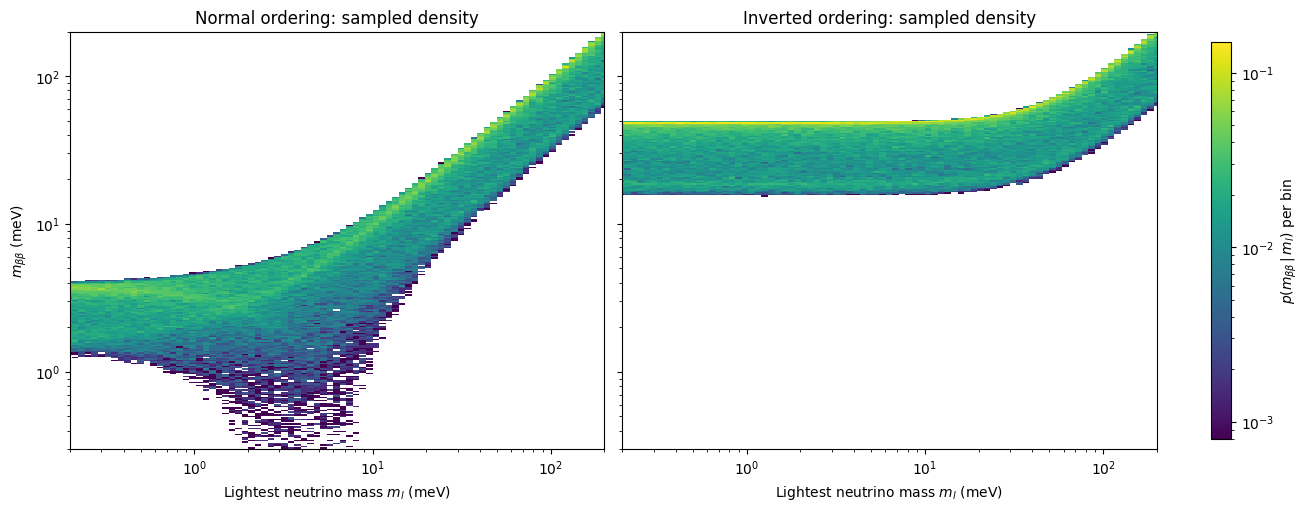

In [23]:
# Quick preview: sampled (m_l, m_bb) distributions only (NO/IO), no experiment bands/probability panels.
x_grid_from_samples_preview = np.unique(np.concatenate([m_NO_pts, m_IO_pts]))
x_bins_preview = lm.x_edges_from_grid(x_grid_from_samples_preview)
y_bins_preview = np.logspace(-1.0, 3.0, 400) * 1e-3

hist_preview = lm.compute_density_histograms(
    m_NO_pts, mbb_NO_pts, m_IO_pts, mbb_IO_pts, x_bins_preview, y_bins_preview
)

x_edges_meV_preview = hist_preview["x_edges"] * 1e3
y_edges_meV_preview = hist_preview["y_edges"] * 1e3

uniform_cmap_preview = plt.get_cmap("viridis").copy()
uniform_cmap_preview.set_bad(alpha=0.0)

# Shared normalization across both panels for direct visual comparison.
norm_preview = LogNorm(vmin=hist_preview["vmin"], vmax=hist_preview["vmax"])

fig, (ax_no_preview, ax_io_preview) = plt.subplots(1, 2, figsize=(13, 5), sharey=True, constrained_layout=True)

pcm_no_preview = ax_no_preview.pcolormesh(
    x_edges_meV_preview,
    y_edges_meV_preview,
    hist_preview["H_no_pdf_masked"].T,
    shading="auto",
    cmap=uniform_cmap_preview,
    norm=norm_preview,
    rasterized=True,
    antialiased=False,
    edgecolors="none",
)
ax_no_preview.set_title("Normal ordering: sampled density")

pcm_io_preview = ax_io_preview.pcolormesh(
    x_edges_meV_preview,
    y_edges_meV_preview,
    hist_preview["H_io_pdf_masked"].T,
    shading="auto",
    cmap=uniform_cmap_preview,
    norm=norm_preview,
    rasterized=True,
    antialiased=False,
    edgecolors="none",
)
ax_io_preview.set_title("Inverted ordering: sampled density")

for ax in (ax_no_preview, ax_io_preview):
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(2e-1, 2e2)
    ax.set_ylim(3e-1, 2e2)
    ax.set_xlabel(r"Lightest neutrino mass $m_l$ (meV)")

ax_no_preview.set_ylabel(r"$m_{\beta\beta}$ (meV)")

cbar_preview = fig.colorbar(pcm_io_preview, ax=[ax_no_preview, ax_io_preview], shrink=0.95)
cbar_preview.set_label(r"$p(m_{\beta\beta}\,|\,m_l)$ per bin")

plt.show()

In [62]:
# Shared setup for 4-panel lobster plots and a reusable plotting helper.
from matplotlib.colors import LogNorm
from matplotlib.ticker import FuncFormatter

_fmt = FuncFormatter(lambda x, _: f"{x:g}")

# Build x-bins directly from sampled m_l values to avoid grid-mismatch artifacts.
x_grid_from_samples = np.unique(np.concatenate([m_NO_pts, m_IO_pts]))
x_bins = lm.x_edges_from_grid(x_grid_from_samples)
y_bins = np.logspace(-1.0, 3.0, 400) * 1e-3

hist = lm.compute_density_histograms(m_NO_pts, mbb_NO_pts, m_IO_pts, mbb_IO_pts, x_bins, y_bins)

# CP-conserving / mu-tau reflection-symmetry phase-curve overlays (theta23, delta_CP
# drop out of m_bb, so these four curves are also mu-tau reflection symmetry's full
# prediction for m_bb -- see Section 7 below).
m_l_model_eV = np.logspace(-4.0, 0.0, 400)
m_l_model_meV = m_l_model_eV * 1e3
model_curves_no = lm.cp_conserving_curves(params_dict_NO, "NO", m_l_model_eV)
model_curves_io = lm.cp_conserving_curves(params_dict_IO, "IO", m_l_model_eV)

# Shared constants for translating T1/2 bands to m_bb bands.
G = 14.58e-15
g_A = 1.273
m_e = 0.511e6

# XLZD exposure assumptions.
halflife_sens_80t = {"upper": 1.3e28, "lower": 8.6e27}
halflife_disc_80t = {"upper": 5.76e27, "lower": 3.81e27}
halflife_sens_60t = {"upper": 9.4e27, "lower": 6.2e27}
halflife_disc_60t = {"upper": 4.06e27, "lower": 2.64e27}

# NME ranges.
nme_ab_initio = {"lower": 1.08, "upper": 1.90}
nme_pheno = {"lower": 1.98, "upper": 5.06}


def mbb_band_from_halflife(nme_band, t_half_band):
    return {
        "upper": np.sqrt(1.0 / (G * g_A**4 * nme_band["upper"] ** 2 * t_half_band["upper"])) * m_e,
        "lower": np.sqrt(1.0 / (G * g_A**4 * nme_band["lower"] ** 2 * t_half_band["lower"])) * m_e,
    }


def mbb_band_fixed_halflife(nme_band, t_half_value):
    # Fixed T1/2: vertical band width comes only from the NME range.
    return {
        "upper": np.sqrt(1.0 / (G * g_A**4 * nme_band["lower"] ** 2 * t_half_value)) * m_e,
        "lower": np.sqrt(1.0 / (G * g_A**4 * nme_band["upper"] ** 2 * t_half_value)) * m_e,
    }


def build_mbb_bands(nme_band, mode):
    if mode == "sensitivity":
        t80 = halflife_sens_80t
        t60 = halflife_sens_60t
    elif mode == "discovery":
        t80 = halflife_disc_80t
        t60 = halflife_disc_60t
    else:
        raise ValueError("mode must be 'sensitivity' or 'discovery'")

    mbb_80t = mbb_band_from_halflife(nme_band, t80)
    mbb_60t = mbb_band_from_halflife(nme_band, t60)
    return mbb_80t, mbb_60t


def plot_four_panel_for_bands(mbb_80t, mbb_60t, title_prefix, show_model_curves=False, flip_probability=False):
    probs_local = lm.discovery_probabilities(
        hist["H_no_pdf"],
        hist["H_io_pdf"],
        hist["y_edges"],
        mbb_80t,
        mbb_60t,
    )
    if flip_probability:
        probs_local = {k: np.clip(1.0 - v, 0.0, 1.0) for k, v in probs_local.items()}

    # Cosmology limits from the legacy notebook (DESI w0-wa): sum_m_nu = 0.163 eV.
    try:
        m_l_no_max, m_l_io_max = lm.cosmological_lightest_limits(0.163, params_dict_NO, params_dict_IO)
    except ValueError:
        m_l_no_max = lm.solve_lightest_from_sum(0.163, params_dict_NO["dm21"], params_dict_NO["dm31"], ordering="NO")
        m_l_io_max = np.nan

    x_edges_meV = hist["x_edges"] * 1e3
    y_edges_meV = hist["y_edges"] * 1e3
    x_centers_meV = 0.5 * (x_edges_meV[:-1] + x_edges_meV[1:])
    m_l_no_max_meV = m_l_no_max * 1e3
    m_l_io_max_meV = m_l_io_max * 1e3 if np.isfinite(m_l_io_max) else np.nan

    mbb_80t_meV = {k: v * 1e3 for k, v in mbb_80t.items()}
    mbb_60t_meV = {k: v * 1e3 for k, v in mbb_60t.items()}

    xlim_meV = (1.0, 2e2)
    ylim_meV = (0.6, 1e2)

    fig, axes = plt.subplots(
        2, 2, figsize=(14, 8),
        sharex="col",
        gridspec_kw={"height_ratios": [1.5, 1]},
        constrained_layout=True,
    )

    uniform_cmap = plt.get_cmap("viridis").copy()
    uniform_cmap.set_bad(alpha=0.0)
    norm_col = LogNorm(vmin=hist["vmin"], vmax=hist["vmax"])

    def add_cosmology_exclusion(ax, x_lim_right, cutoff_meV):
        if not np.isfinite(cutoff_meV):
            return
        ax.axvspan(cutoff_meV, x_lim_right, facecolor="white", alpha=0.32, hatch="///", edgecolor="0.4", linewidth=0.0)
        ax.axvline(cutoff_meV, color="0.2", linestyle="--", linewidth=1.2)

    def add_xlzd_bands(ax):
        ax.fill_between(x_edges_meV, mbb_80t_meV["upper"], mbb_80t_meV["lower"], color="gray", alpha=0.35, label="XLZD 80 t")
        ax.fill_between(x_edges_meV, mbb_60t_meV["upper"], mbb_60t_meV["lower"], color="orange", alpha=0.35, label="XLZD 60 t")

    def add_model_curves(ax, curves):
        ax.plot(m_l_model_meV, curves["(0, 0)"], color="black", lw=1.6, ls="-", label=r"$\mu\tau$-refl. sym. (max)")
        ax.plot(m_l_model_meV, curves["(0, pi)"], color="black", lw=1.6, ls="--", label=r"$\mu\tau$-refl. sym. (min)")

    # Top-left: NO density
    ax = axes[0, 0]
    pcm_no = ax.pcolormesh(x_edges_meV, y_edges_meV, hist["H_no_pdf_masked"].T, shading="auto", cmap=uniform_cmap, norm=norm_col)
    ax.set_title(f"{title_prefix}: Normal ordering")
    ax.set_yscale("log")
    ax.set_ylabel(r"$m_{\beta\beta}$ (meV)")
    ax.set_xlim(*xlim_meV)
    ax.set_ylim(*ylim_meV)
    add_xlzd_bands(ax)
    if show_model_curves:
        add_model_curves(ax, model_curves_no)
    add_cosmology_exclusion(ax, xlim_meV[1], m_l_no_max_meV)
    ax.text(1.08 * m_l_no_max_meV, 0.64, 'Excl. by $w_0 w_a$\ncosmology', fontsize=9.2, color='0.2', rotation=0, va='bottom')
    ax.legend(loc="upper left", fontsize=8.8, frameon=False)
    ax.yaxis.set_major_formatter(_fmt)
    cb_no = fig.colorbar(pcm_no, ax=ax)
    cb_no.set_label(r"$p(m_{\beta\beta}\,|\,m_l)$ per bin")

    # Top-right: IO density
    ax = axes[0, 1]
    pcm_io = ax.pcolormesh(x_edges_meV, y_edges_meV, hist["H_io_pdf_masked"].T, shading="auto", cmap=uniform_cmap, norm=norm_col)
    ax.set_title(f"{title_prefix}: Inverted ordering")
    ax.set_yscale("log")
    ax.set_ylabel(r"$m_{\beta\beta}$ (meV)")
    ax.set_xlim(*xlim_meV)
    ax.set_ylim(*ylim_meV)
    add_xlzd_bands(ax)
    if show_model_curves:
        add_model_curves(ax, model_curves_io)
    add_cosmology_exclusion(ax, xlim_meV[1], m_l_io_max_meV)
    if np.isfinite(m_l_io_max_meV):
        ax.text(1.08 * m_l_io_max_meV, 0.64, 'Excl. by $w_0 w_a$\ncosmology', fontsize=9.2, color='0.2', rotation=0, va='bottom')
    ax.legend(loc="upper left", fontsize=8.8, frameon=False)
    ax.yaxis.set_major_formatter(_fmt)
    cb_io = fig.colorbar(pcm_io, ax=ax)
    cb_io.set_label(r"$p(m_{\beta\beta}\,|\,m_l)$ per bin")

    # Bottom-left: NO probability
    ax = axes[1, 0]
    add_cosmology_exclusion(ax, xlim_meV[1], m_l_no_max_meV)
    ax.plot(x_centers_meV, probs_local["no_80t"], color="gray", lw=1.9, label="80 t")
    ax.plot(x_centers_meV, probs_local["no_60t"], color="orange", lw=1.9, label="60 t")
    ax.set_xscale("log")
    ax.set_xlabel(r"Lightest neutrino mass $m_l$ (meV)")
    ax.set_ylabel("P")
    ax.set_xlim(*xlim_meV)
    ax.set_ylim(0.0, 1.05)
    ax.legend(loc="upper left", fontsize=9, frameon=False)
    ax.xaxis.set_major_formatter(_fmt)

    # Bottom-right: IO probability
    ax = axes[1, 1]
    add_cosmology_exclusion(ax, xlim_meV[1], m_l_io_max_meV)
    ax.plot(x_centers_meV, probs_local["io_80t"], color="gray", lw=1.9, label="80 t")
    ax.plot(x_centers_meV, probs_local["io_60t"], color="orange", lw=1.9, label="60 t")
    ax.set_xscale("log")
    ax.set_xlabel(r"Lightest neutrino mass $m_l$ (meV)")
    ax.set_ylabel("P")
    ax.set_xlim(*xlim_meV)
    ax.set_ylim(0.0, 1.05)
    ax.legend(loc="upper left", fontsize=9, frameon=False)
    ax.xaxis.set_major_formatter(_fmt)

   


## 5b. XLZD Sensitivity Overlays on Sampled Density (2-Panel Figures)

These plots overlay XLZD **80 t sensitivity** bands on the sampled density maps only (no discovery-probability panels). For each NME scenario (ab-initio and phenomenological), two 80 t half-life assumptions are shown as separate bands: the upper and lower sensitivity estimates. Because each band uses a fixed half-life, its thickness is driven only by the NME spread.

80 t sensitivity m_bb band (upper estimate): {'upper': 21.307832030780474, 'lower': 12.111820312233112}
80 t sensitivity m_bb band (lower estimate): {'upper': 26.197612566698034, 'lower': 14.891274511596777}


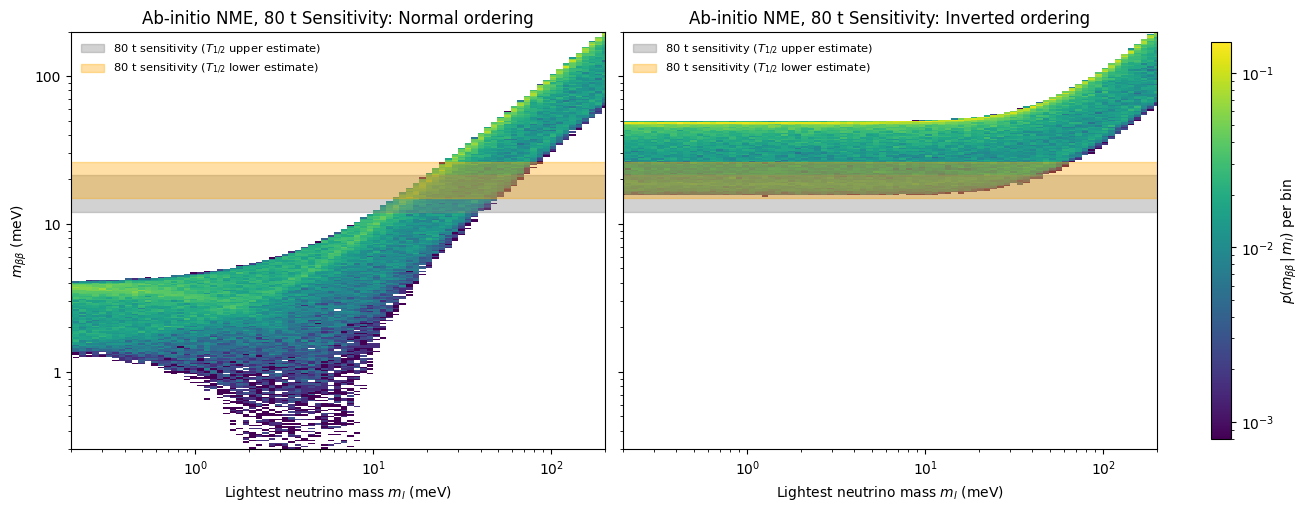

80 t sensitivity m_bb band (upper estimate): {'upper': 11.622453834971166, 'lower': 4.547916718032196}
80 t sensitivity m_bb band (lower estimate): {'upper': 14.289606854562562, 'lower': 5.591585290915787}


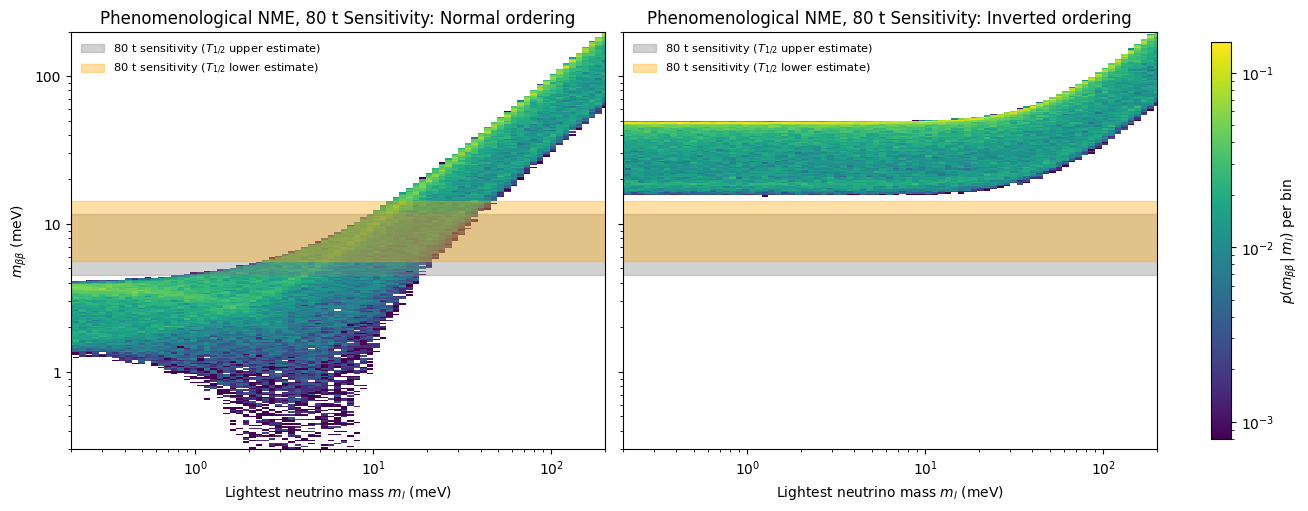

In [63]:
def mbb_band_fixed_halflife_from_nme(nme_band, t_half_value):
    # For fixed T1/2, band width comes only from NME uncertainty.
    g_A = 1.27
    return {
        "upper": np.sqrt(1.0 / (G * g_A**4 * nme_band["lower"] ** 2 * t_half_value)) * m_e,
        "lower": np.sqrt(1.0 / (G * g_A**4 * nme_band["upper"] ** 2 * t_half_value)) * m_e,
    }


def plot_two_panel_density_with_80t_sensitivity_bounds(nme_band, title_prefix):
    mbb_80t_upper_est = mbb_band_fixed_halflife_from_nme(
        nme_band, halflife_sens_80t["upper"]
    )
    mbb_80t_lower_est = mbb_band_fixed_halflife_from_nme(
        nme_band, halflife_sens_80t["lower"]
    )


    x_edges_meV = hist["x_edges"] * 1e3
    y_edges_meV = hist["y_edges"] * 1e3
    mbb_upper_est_meV = {k: v * 1e3 for k, v in mbb_80t_upper_est.items()}
    mbb_lower_est_meV = {k: v * 1e3 for k, v in mbb_80t_lower_est.items()}
    
    # Print the calculated m_bb bands for 80 t sensitivity
    print(f"80 t sensitivity m_bb band (upper estimate): {mbb_upper_est_meV}")
    print(f"80 t sensitivity m_bb band (lower estimate): {mbb_lower_est_meV}")

    fig, (ax_no, ax_io) = plt.subplots(
        1, 2, figsize=(13, 5), sharey=True, constrained_layout=True
    )

    cmap_local = plt.get_cmap("viridis").copy()
    cmap_local.set_bad(alpha=0.0)
    norm_local = LogNorm(vmin=hist["vmin"], vmax=hist["vmax"])

    pcm_no = ax_no.pcolormesh(
        x_edges_meV,
        y_edges_meV,
        hist["H_no_pdf_masked"].T,
        shading="auto",
        cmap=cmap_local,
        norm=norm_local,
        rasterized=True,
        antialiased=False,
        edgecolors="none",
    )
    ax_no.fill_between(
        x_edges_meV,
        mbb_upper_est_meV["upper"],
        mbb_upper_est_meV["lower"],
        color="gray",
        alpha=0.35,
        label=r"80 t sensitivity ($T_{1/2}$ upper estimate)",
    )
    ax_no.fill_between(
        x_edges_meV,
        mbb_lower_est_meV["upper"],
        mbb_lower_est_meV["lower"],
        color="orange",
        alpha=0.35,
        label=r"80 t sensitivity ($T_{1/2}$ lower estimate)",
    )
    ax_no.set_title(f"{title_prefix}: Normal ordering")

    pcm_io = ax_io.pcolormesh(
        x_edges_meV,
        y_edges_meV,
        hist["H_io_pdf_masked"].T,
        shading="auto",
        cmap=cmap_local,
        norm=norm_local,
        rasterized=True,
        antialiased=False,
        edgecolors="none",
    )
    ax_io.fill_between(
        x_edges_meV,
        mbb_upper_est_meV["upper"],
        mbb_upper_est_meV["lower"],
        color="gray",
        alpha=0.35,
        label=r"80 t sensitivity ($T_{1/2}$ upper estimate)",
    )
    ax_io.fill_between(
        x_edges_meV,
        mbb_lower_est_meV["upper"],
        mbb_lower_est_meV["lower"],
        color="orange",
        alpha=0.35,
        label=r"80 t sensitivity ($T_{1/2}$ lower estimate)",
    )
    ax_io.set_title(f"{title_prefix}: Inverted ordering")

    for ax in (ax_no, ax_io):
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlim(2e-1, 2e2)
        ax.set_ylim(3e-1, 2e2)
        ax.set_xlabel(r"Lightest neutrino mass $m_l$ (meV)")
        ax.yaxis.set_major_formatter(_fmt)
        ax.legend(loc="upper left", fontsize=8.2, frameon=False)

    ax_no.set_ylabel(r"$m_{\beta\beta}$ (meV)")

    cbar = fig.colorbar(pcm_io, ax=[ax_no, ax_io], shrink=0.95)
    cbar.set_label(r"$p(m_{\beta\beta}\,|\,m_l)$ per bin")

    plt.show()

# Figure 1: ab-initio NMEs (NO + IO panels)
plot_two_panel_density_with_80t_sensitivity_bounds(
    nme_ab_initio, "Ab-initio NME, 80 t Sensitivity"
 )

# Figure 2: phenomenological NMEs (NO + IO panels)
plot_two_panel_density_with_80t_sensitivity_bounds(
    nme_pheno, "Phenomenological NME, 80 t Sensitivity"
 )

## 5c. XLZD 60 t Sensitivity Overlays on Sampled Density (2-Panel Figures)

These plots repeat Section 5b for the **60 t sensitivity** case. For each NME scenario (ab-initio and phenomenological), two 60 t half-life assumptions are shown as separate bands: the upper and lower sensitivity estimates. Because each band uses a fixed half-life, its thickness is driven only by the NME spread.

60 t sensitivity bounds (upper estimate): {'upper': 25.05803514073689, 'lower': 14.24351471157676}
60 t sensitivity bounds (lower estimate): {'upper': 30.85425723769058, 'lower': 17.538209377213597}


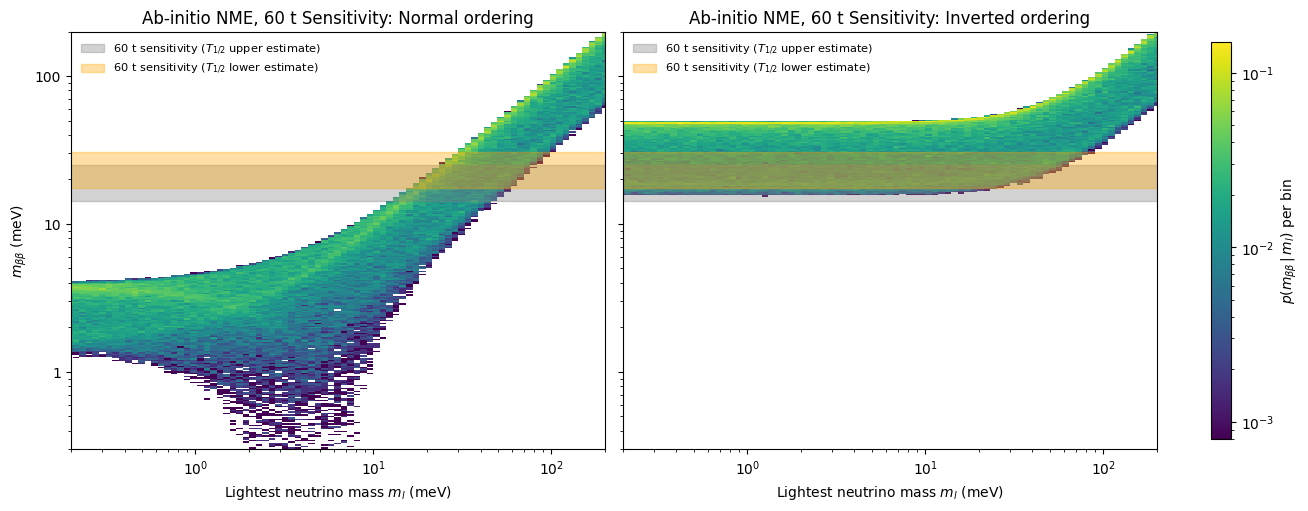

60 t sensitivity bounds (upper estimate): {'upper': 24.380790947744, 'lower': 5.6735173903555225}
60 t sensitivity bounds (lower estimate): {'upper': 30.020358393428676, 'lower': 6.9858695632506995}


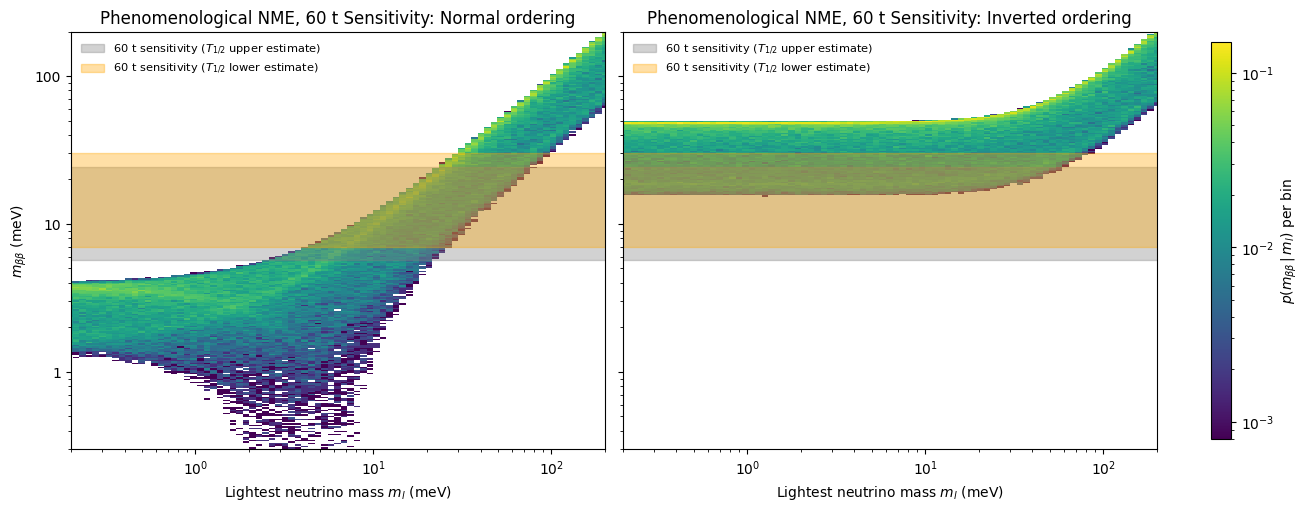

In [ ]:
def plot_two_panel_density_with_60t_sensitivity_bounds(nme_band, title_prefix):
    mbb_60t_upper_est = mbb_band_fixed_halflife_from_nme(
        nme_band, halflife_sens_60t["upper"]
    )
    mbb_60t_lower_est = mbb_band_fixed_halflife_from_nme(
        nme_band, halflife_sens_60t["lower"]
    )

    x_edges_meV = hist["x_edges"] * 1e3
    y_edges_meV = hist["y_edges"] * 1e3
    mbb_upper_est_meV = {k: v * 1e3 for k, v in mbb_60t_upper_est.items()}
    mbb_lower_est_meV = {k: v * 1e3 for k, v in mbb_60t_lower_est.items()}

    # Print the mbb ranges for debugging purposes:
    print(f"60 t sensitivity bounds (upper estimate): {mbb_upper_est_meV}")
    print(f"60 t sensitivity bounds (lower estimate): {mbb_lower_est_meV}")


    fig, (ax_no, ax_io) = plt.subplots(
        1, 2, figsize=(13, 5), sharey=True, constrained_layout=True
    )

    cmap_local = plt.get_cmap("viridis").copy()
    cmap_local.set_bad(alpha=0.0)
    norm_local = LogNorm(vmin=hist["vmin"], vmax=hist["vmax"])

    pcm_no = ax_no.pcolormesh(
        x_edges_meV,
        y_edges_meV,
        hist["H_no_pdf_masked"].T,
        shading="auto",
        cmap=cmap_local,
        norm=norm_local,
        rasterized=True,
        antialiased=False,
        edgecolors="none",
    )
    ax_no.fill_between(
        x_edges_meV,
        mbb_upper_est_meV["upper"],
        mbb_upper_est_meV["lower"],
        color="gray",
        alpha=0.35,
        label=r"60 t sensitivity ($T_{1/2}$ upper estimate)",
    )
    ax_no.fill_between(
        x_edges_meV,
        mbb_lower_est_meV["upper"],
        mbb_lower_est_meV["lower"],
        color="orange",
        alpha=0.35,
        label=r"60 t sensitivity ($T_{1/2}$ lower estimate)",
    )
    ax_no.set_title(f"{title_prefix}: Normal ordering")

    pcm_io = ax_io.pcolormesh(
        x_edges_meV,
        y_edges_meV,
        hist["H_io_pdf_masked"].T,
        shading="auto",
        cmap=cmap_local,
        norm=norm_local,
        rasterized=True,
        antialiased=False,
        edgecolors="none",
    )
    ax_io.fill_between(
        x_edges_meV,
        mbb_upper_est_meV["upper"],
        mbb_upper_est_meV["lower"],
        color="gray",
        alpha=0.35,
        label=r"60 t sensitivity ($T_{1/2}$ upper estimate)",
    )
    ax_io.fill_between(
        x_edges_meV,
        mbb_lower_est_meV["upper"],
        mbb_lower_est_meV["lower"],
        color="orange",
        alpha=0.35,
        label=r"60 t sensitivity ($T_{1/2}$ lower estimate)",
    )
    ax_io.set_title(f"{title_prefix}: Inverted ordering")

    for ax in (ax_no, ax_io):
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlim(2e-1, 2e2)
        ax.set_ylim(3e-1, 2e2)
        ax.set_xlabel(r"Lightest neutrino mass $m_l$ (meV)")
        ax.yaxis.set_major_formatter(_fmt)
        ax.legend(loc="upper left", fontsize=8.2, frameon=False)

    ax_no.set_ylabel(r"$m_{\beta\beta}$ (meV)")

    cbar = fig.colorbar(pcm_io, ax=[ax_no, ax_io], shrink=0.95)
    cbar.set_label(r"$p(m_{\beta\beta}\,|\,m_l)$ per bin")

    plt.show()

# Figure 1: ab-initio NMEs (NO + IO panels)
plot_two_panel_density_with_60t_sensitivity_bounds(
    nme_ab_initio, "Ab-initio NME, 60 t Sensitivity"
 )

# Figure 2: phenomenological NMEs (NO + IO panels)
plot_two_panel_density_with_60t_sensitivity_bounds(
    nme_pheno, "Phenomenological NME, 60 t Sensitivity"
 )

## 6a. Ab-initio NMEs — Sensitivity Reach

The **sensitivity** half-lives represent the $m_{\beta\beta}$ values at which XLZD would begin to exclude signal at 90% CL ($T^{1/2}_{80\text{t}} \in [8.6,\,13]\times10^{27}$ yr, $T^{1/2}_{60\text{t}} \in [6.2,\,9.4]\times10^{27}$ yr). The NME uncertainty is taken from ab-initio shell-model calculations ($|M_{0\nu}| \in [1.08,\,1.90]$). The hatched region is excluded by the DESI $w_0 w_a$ cosmological bound $\Sigma m_\nu < 0.163$ eV.

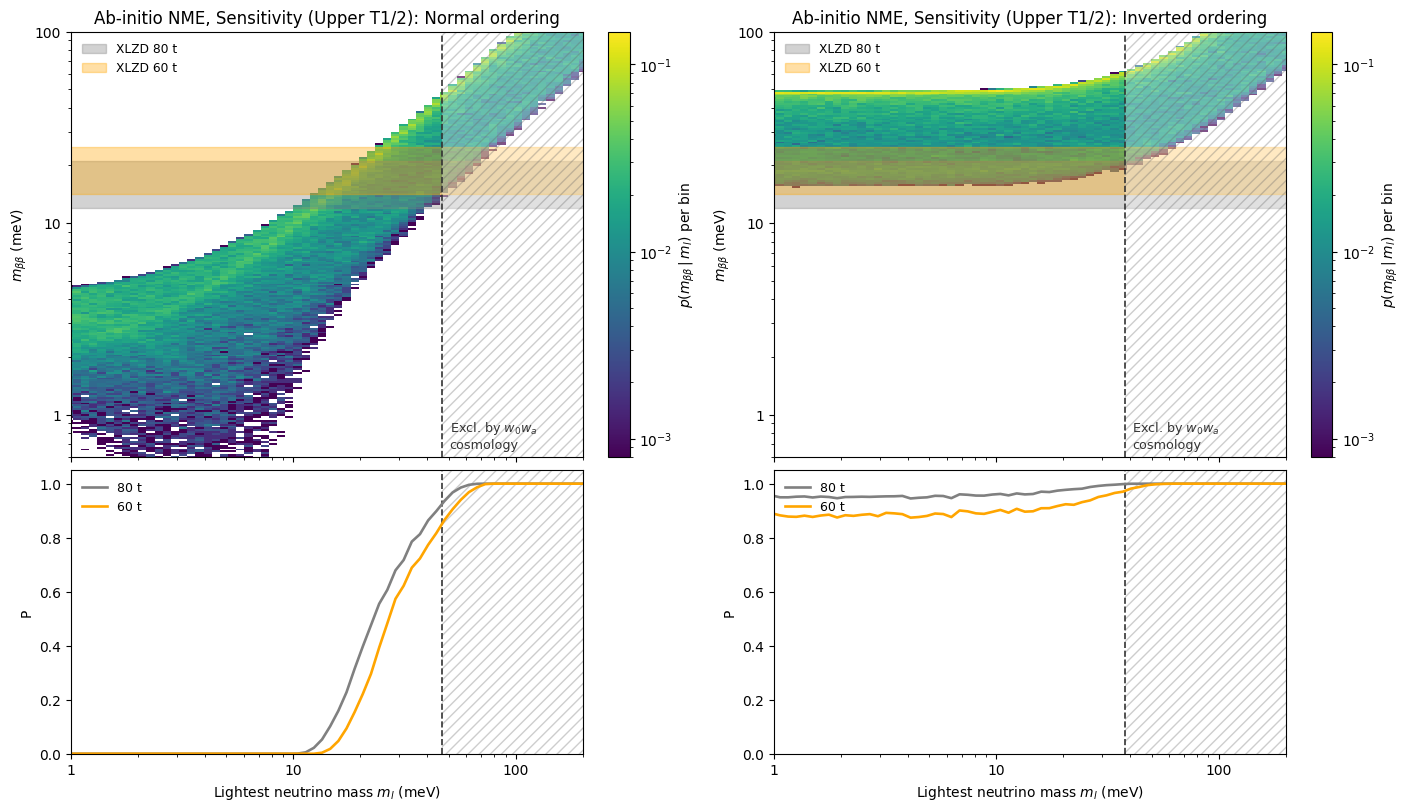

In [54]:
# Plot 1/4: Ab-initio NMEs with sensitivity assumptions (upper T1/2 only)
mbb_80t = mbb_band_fixed_halflife(nme_ab_initio, halflife_sens_80t["upper"])
mbb_60t = mbb_band_fixed_halflife(nme_ab_initio, halflife_sens_60t["upper"])
plot_four_panel_for_bands(
    mbb_80t,
    mbb_60t,
    title_prefix="Ab-initio NME, Sensitivity (Upper T1/2)",
    flip_probability=True,
    show_model_curves=False,
)

## 6b. Ab-initio NMEs — Discovery Potential

Same layout as §6a but with **discovery** half-lives ($T^{1/2}_{80\text{t}} \in [3.81,\,5.76]\times10^{27}$ yr, $T^{1/2}_{60\text{t}} \in [2.64,\,4.06]\times10^{27}$ yr). The bottom panels show $P(\text{discovery} \mid m_l)$ for each mass ordering.

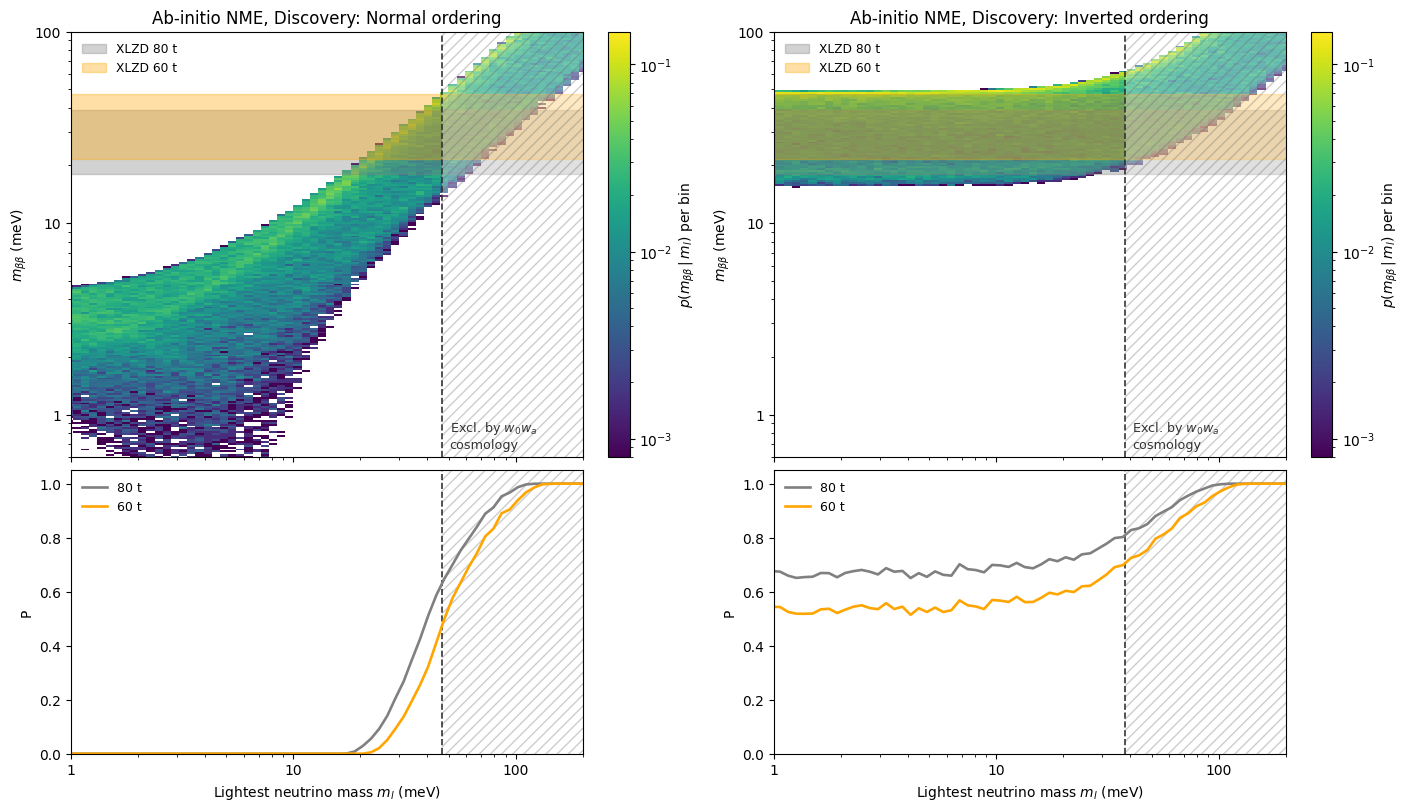

In [55]:
# Plot 2/4: Ab-initio NMEs with discovery assumptions
mbb_80t, mbb_60t = build_mbb_bands(nme_ab_initio, mode="discovery")
plot_four_panel_for_bands(
    mbb_80t,
    mbb_60t,
    title_prefix="Ab-initio NME, Discovery",
    flip_probability=False,
    show_model_curves=False,
)

## 6c. Phenomenological NMEs — Sensitivity Reach

Sensitivity plot using **phenomenological (QRPA-based) NME** estimates ($|M_{0\nu}| \in [1.98,\,5.06]$). These larger NME values lower the $m_{\beta\beta}$ thresholds, shifting the shaded sensitivity bands downward relative to the ab-initio case.

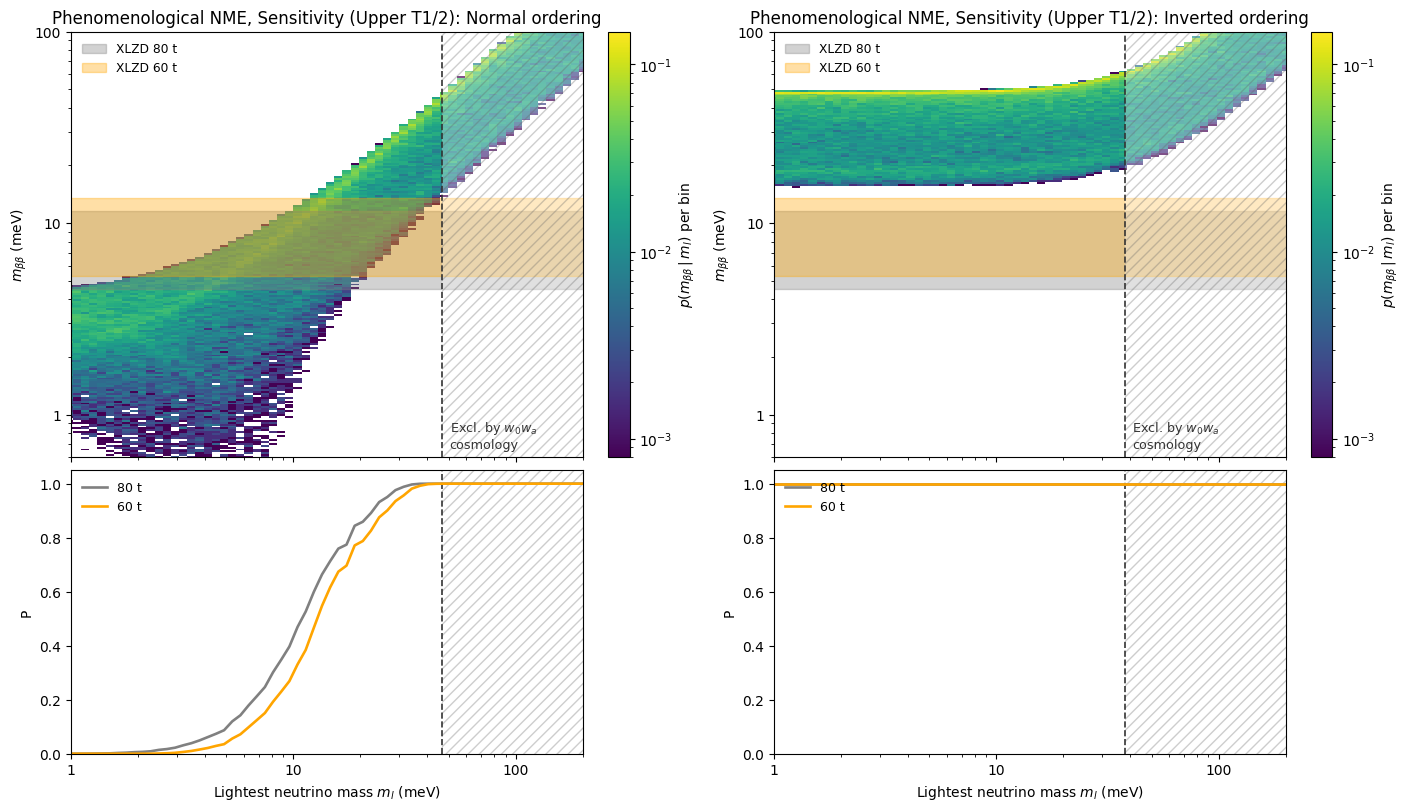

In [56]:
# Plot 3/4: Phenomenological NMEs with sensitivity assumptions (upper T1/2 only)
mbb_80t = mbb_band_fixed_halflife(nme_pheno, halflife_sens_80t["upper"])
mbb_60t = mbb_band_fixed_halflife(nme_pheno, halflife_sens_60t["upper"])
plot_four_panel_for_bands(
    mbb_80t,
    mbb_60t,
    title_prefix="Phenomenological NME, Sensitivity (Upper T1/2)",
    flip_probability=True,
    show_model_curves=False,
)

## 6d. Phenomenological NMEs — Discovery Potential

Same as §6c but using **discovery** half-lives. Compare with §6b to see how the much larger phenomenological NME values shift the discovery reach relative to the ab-initio case.

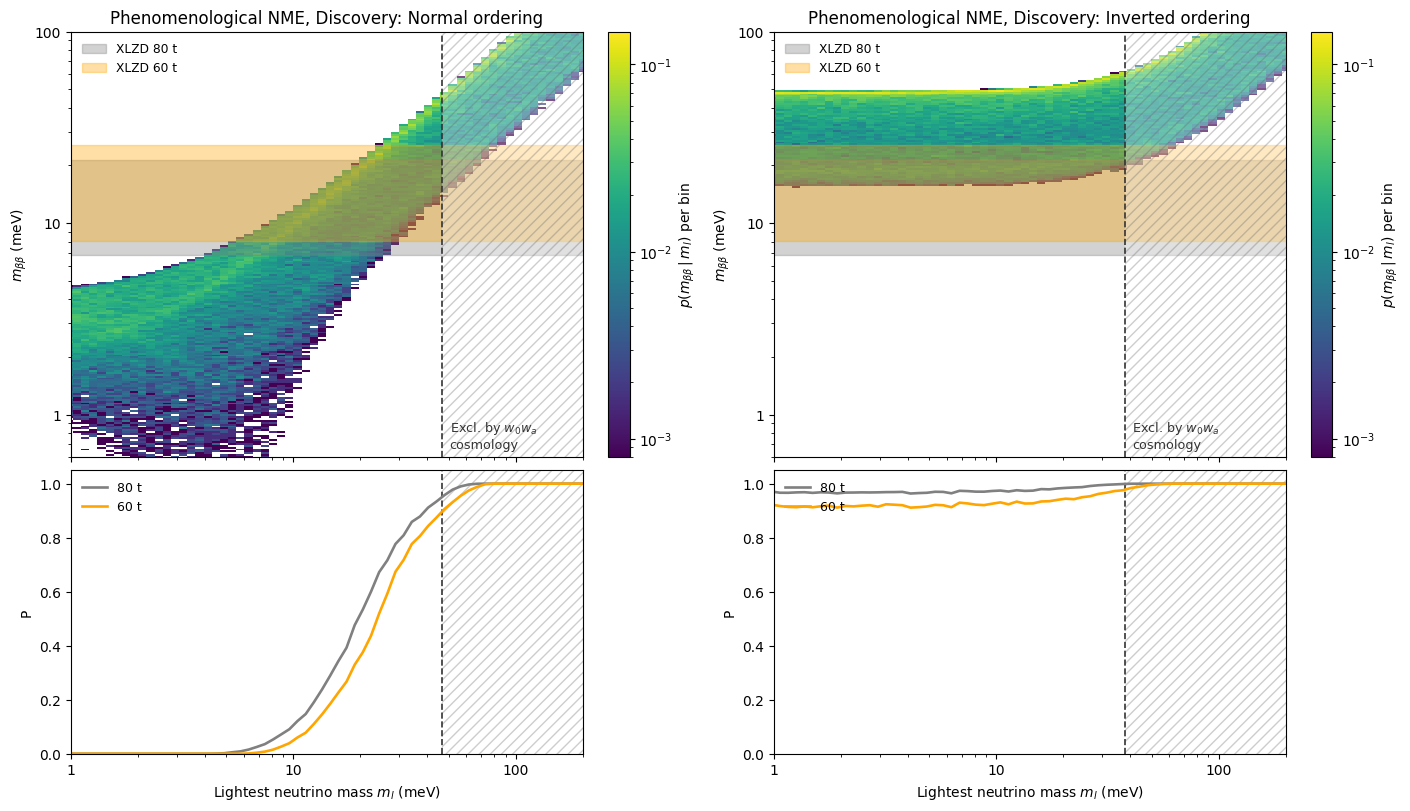

In [57]:
# Plot 4/4: Phenomenological NMEs with discovery assumptions
mbb_80t, mbb_60t = build_mbb_bands(nme_pheno, mode="discovery")
plot_four_panel_for_bands(
    mbb_80t,
    mbb_60t,
    title_prefix="Phenomenological NME, Discovery",
    flip_probability=False,
    show_model_curves=False,
)

## 7. CP-Conserving / $\mu$-$\tau$ Reflection-Symmetry Phase Curves

Curves tracing $|m_{\beta\beta}|(m_l)$ at best-fit oscillation parameters for the four CP-conserving Majorana phase combinations $(\alpha_1, \alpha_2) \in \{0, \pi\}^2$. Because $|m_{\beta\beta}|$ depends only on $\theta_{12}$, $\theta_{13}$, the mass splittings, and the two Majorana phases $\alpha_1, \alpha_2$ -- the Dirac phase $\delta_{CP}$ and $\theta_{23}$ drop out entirely -- this is also the complete set of predictions from **$\mu$-$\tau$ reflection symmetry**, which fixes $\theta_{23} = \pi/4$, $\delta_{CP} = \pm\pi/2$, and forces the Majorana phases to be CP-conserving without picking out a unique combination among the four. Note that $(0,0)$ and $(\pi,\pi)$ coincide at small $m_l$ (constructive interference, the upper edge of the band), while $(0,\pi)$ and $(\pi,0)$ coincide there too (destructive interference, the cancellation notch visible in the Normal Ordering density plots above). The four curves together exactly bound the Monte Carlo phase-density shown in Section 6, and the (max, min) pair is overlaid directly on those density panels as black solid/dashed lines.


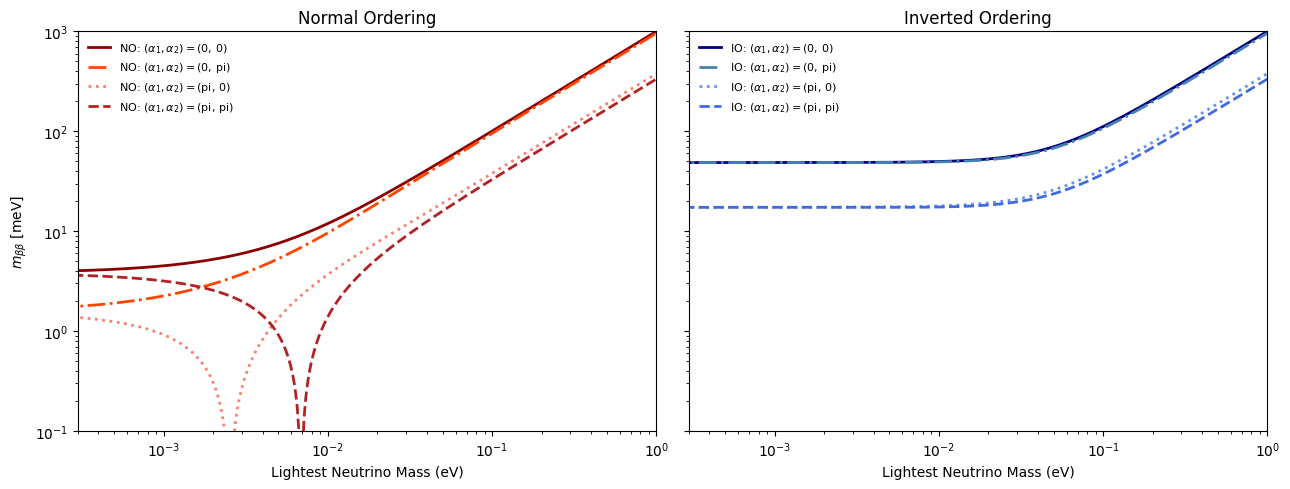

In [43]:
curves_no = lm.cp_conserving_curves(params_dict_NO, "NO", m_l_model_eV)
curves_io = lm.cp_conserving_curves(params_dict_IO, "IO", m_l_model_eV)

styles_no = {
    "(0, 0)": dict(color="darkred", lw=2, ls="-"),
    "(pi, pi)": dict(color="firebrick", lw=2, ls="--"),
    "(0, pi)": dict(color="orangered", lw=2, ls="-."),
    "(pi, 0)": dict(color="salmon", lw=2, ls=":"),
}
styles_io = {
    "(0, 0)": dict(color="navy", lw=2, ls="-"),
    "(pi, pi)": dict(color="royalblue", lw=2, ls="--"),
    "(0, pi)": dict(color="steelblue", lw=2, ls="-."),
    "(pi, 0)": dict(color="cornflowerblue", lw=2, ls=":"),
}

fig, (ax_no, ax_io) = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for label, curve in curves_no.items():
    ax_no.plot(m_l_model_eV, curve, label=fr"NO: $(\alpha_1,\alpha_2)=${label}", **styles_no[label])
for label, curve in curves_io.items():
    ax_io.plot(m_l_model_eV, curve, label=fr"IO: $(\alpha_1,\alpha_2)=${label}", **styles_io[label])

for ax, title in [(ax_no, "Normal Ordering"), (ax_io, "Inverted Ordering")]:
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(3e-4, 1.0)
    ax.set_ylim(1e-1, 1e3)
    ax.set_title(title)
    ax.set_xlabel("Lightest Neutrino Mass (eV)")
    ax.legend(frameon=False, fontsize=8)

ax_no.set_ylabel(r"$m_{\beta\beta}$ [meV]")
plt.tight_layout()
plt.show()


In [44]:
# Okay, now let's do a study of how the XLZD discovery probability 
# compares to LEGEND-1000

# Shared constants for translating T1/2 bands to m_bb bands.
G = 2.363e-15
g_A = 1.273
m_e = 0.511e6

# L-1000 exposure assumptions.
halflife_disc_L1000 = {'upper': 1e28 }

# NME ranges.
nme_ab_initio = {"lower": 2.09, "upper": 3.09}
nme_pheno = {"lower": 2.37, "upper": 9.07}



## 8. LEGEND-1000 Conditional Discovery Probability

Given a LEGEND-1000 discovery (measured half-life of $1 \times 10^{28}$ yr), what is the probability that XLZD (80 t and 60 t) will also observe a signal? This section computes $P(\text{XLZD discovery} \mid \text{LEGEND discovery})$ as a function of $m_l$ for both ab-initio and phenomenological NME scenarios. The conditional probability is computed by combining the discovery weights for both experiments at each $m_{\beta\beta}$ point and marginalizing over the $m_l$-dependent density distribution.

In [14]:
# Reload the module to ensure all functions are available
import importlib
importlib.reload(lm)

# LEGEND-1000 has a single fixed discovery half-life (not a band like XLZD).
halflife_disc_L1000 = {'upper': 1e28, 'lower': 1e28}

# LEGEND-1000 constants (isotope-specific G value).
G_L1000 = 2.363e-15
g_A = 1.273
m_e = 0.511e6

# LEGEND-1000 NME ranges (different isotope/calc than XLZD).
nme_ab_initio_L1000 = {"lower": 2.09, "upper": 3.09}
nme_pheno_L1000 = {"lower": 2.37, "upper": 9.07}

# Compute LEGEND-1000 m_bb bands using the isotope-specific G and NME ranges.
# Use the same formula as mbb_band_single_halflife but inlined for clarity.
mbb_legend_ab = {
    "upper": np.sqrt(1.0 / (G_L1000 * g_A**4 * nme_ab_initio_L1000["lower"] ** 2 * halflife_disc_L1000['upper'])) * m_e,
    "lower": np.sqrt(1.0 / (G_L1000 * g_A**4 * nme_ab_initio_L1000["upper"] ** 2 * halflife_disc_L1000['upper'])) * m_e,
}

mbb_legend_pheno = {
    "upper": np.sqrt(1.0 / (G_L1000 * g_A**4 * nme_pheno_L1000["lower"] ** 2 * halflife_disc_L1000['upper'])) * m_e,
    "lower": np.sqrt(1.0 / (G_L1000 * g_A**4 * nme_pheno_L1000["upper"] ** 2 * halflife_disc_L1000['upper'])) * m_e,
}

print("LEGEND-1000 m_bb band (ab-initio NME):")
print(f"  Upper: {mbb_legend_ab['upper'] * 1e3:.3f} meV, Lower: {mbb_legend_ab['lower'] * 1e3:.3f} meV")
print("LEGEND-1000 m_bb band (phenomenological NME):")
print(f"  Upper: {mbb_legend_pheno['upper'] * 1e3:.3f} meV, Lower: {mbb_legend_pheno['lower'] * 1e3:.3f} meV")

LEGEND-1000 m_bb band (ab-initio NME):
  Upper: 31.037 meV, Lower: 20.993 meV
LEGEND-1000 m_bb band (phenomenological NME):
  Upper: 27.371 meV, Lower: 7.152 meV


In [15]:
# For each NME scenario and XLZD variant, compute P(XLZD discovery | LEGEND discovery).

# Ab-initio NME case:
mbb_xlzd_80t_ab, mbb_xlzd_60t_ab = build_mbb_bands(nme_ab_initio, mode="discovery")

p_xlzd_80t_cond_legend_ab = lm.conditional_discovery_probability(
    hist["H_no_pdf"], hist["y_edges"], mbb_legend_ab, mbb_xlzd_80t_ab
)
p_xlzd_60t_cond_legend_ab = lm.conditional_discovery_probability(
    hist["H_no_pdf"], hist["y_edges"], mbb_legend_ab, mbb_xlzd_60t_ab
)

# Phenomenological NME case:
mbb_xlzd_80t_pheno, mbb_xlzd_60t_pheno = build_mbb_bands(nme_pheno, mode="discovery")

p_xlzd_80t_cond_legend_pheno = lm.conditional_discovery_probability(
    hist["H_no_pdf"], hist["y_edges"], mbb_legend_pheno, mbb_xlzd_80t_pheno
)
p_xlzd_60t_cond_legend_pheno = lm.conditional_discovery_probability(
    hist["H_no_pdf"], hist["y_edges"], mbb_legend_pheno, mbb_xlzd_60t_pheno
)

print("Conditional probabilities computed.")

Conditional probabilities computed.


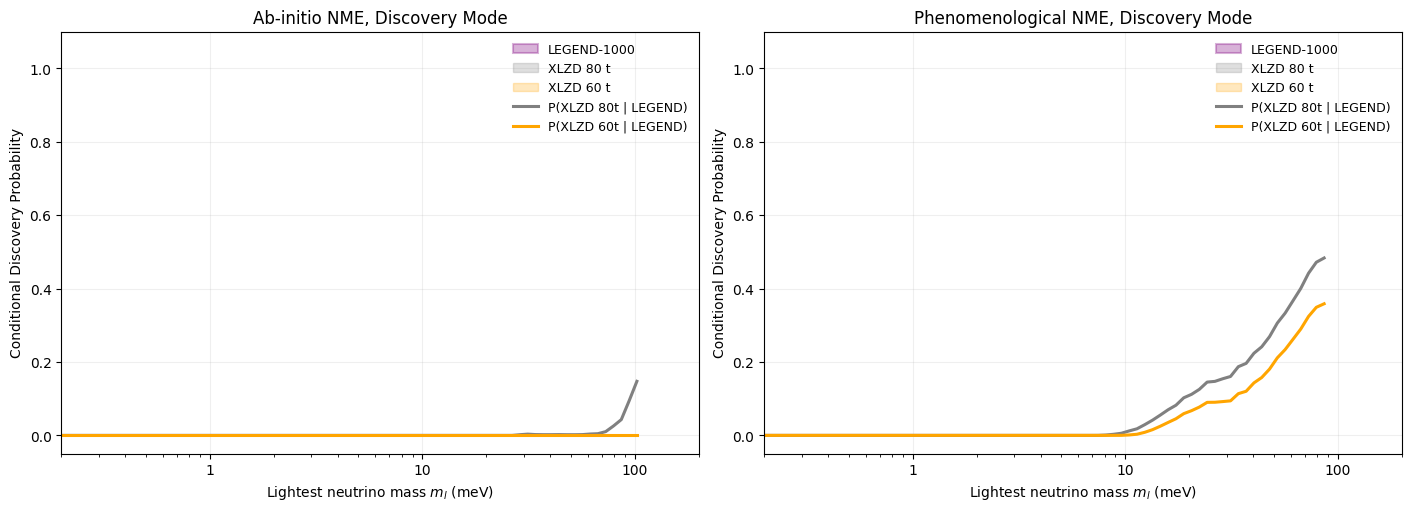

In [16]:
# Two-panel comparison showing LEGEND band + XLZD bands + conditional probability curves.

x_edges_meV = hist["x_edges"] * 1e3
x_centers_meV = 0.5 * (x_edges_meV[:-1] + x_edges_meV[1:])

mbb_legend_ab_meV = {k: v * 1e3 for k, v in mbb_legend_ab.items()}
mbb_legend_pheno_meV = {k: v * 1e3 for k, v in mbb_legend_pheno.items()}

mbb_xlzd_80t_ab_meV = {k: v * 1e3 for k, v in mbb_xlzd_80t_ab.items()}
mbb_xlzd_60t_ab_meV = {k: v * 1e3 for k, v in mbb_xlzd_60t_ab.items()}

mbb_xlzd_80t_pheno_meV = {k: v * 1e3 for k, v in mbb_xlzd_80t_pheno.items()}
mbb_xlzd_60t_pheno_meV = {k: v * 1e3 for k, v in mbb_xlzd_60t_pheno.items()}

fig, (ax_ab, ax_pheno) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# Helper function to plot a panel
def plot_legend_xlzd_comparison(ax, title, mbb_legend, mbb_xlzd_80t, mbb_xlzd_60t, p_80t, p_60t):
    ax.fill_between(x_edges_meV, mbb_legend["upper"], mbb_legend["lower"], 
                     color="purple", alpha=0.3, label="LEGEND-1000", edgecolor="purple", linewidth=1.5)
    ax.fill_between(x_edges_meV, mbb_xlzd_80t["upper"], mbb_xlzd_80t["lower"], 
                     color="gray", alpha=0.25, label="XLZD 80 t")
    ax.fill_between(x_edges_meV, mbb_xlzd_60t["upper"], mbb_xlzd_60t["lower"], 
                     color="orange", alpha=0.25, label="XLZD 60 t")
    
    ax.plot(x_centers_meV, p_80t, color="gray", lw=2.2, label=r"P(XLZD 80t | LEGEND)")
    ax.plot(x_centers_meV, p_60t, color="orange", lw=2.2, label=r"P(XLZD 60t | LEGEND)")
    
    ax.set_xscale("log")
    ax.set_xlabel(r"Lightest neutrino mass $m_l$ (meV)")
    ax.set_ylabel("Conditional Discovery Probability")
    ax.set_xlim(2e-1, 2e2)
    ax.set_ylim(-0.05, 1.1)
    ax.set_title(title)
    ax.legend(loc="best", fontsize=9, frameon=False)
    ax.grid(True, alpha=0.2)
    ax.xaxis.set_major_formatter(_fmt)

# Left panel: ab-initio NMEs
plot_legend_xlzd_comparison(
    ax_ab,
    "Ab-initio NME, Discovery Mode",
    mbb_legend_ab_meV,
    mbb_xlzd_80t_ab_meV,
    mbb_xlzd_60t_ab_meV,
    p_xlzd_80t_cond_legend_ab,
    p_xlzd_60t_cond_legend_ab
)

# Right panel: phenomenological NMEs
plot_legend_xlzd_comparison(
    ax_pheno,
    "Phenomenological NME, Discovery Mode",
    mbb_legend_pheno_meV,
    mbb_xlzd_80t_pheno_meV,
    mbb_xlzd_60t_pheno_meV,
    p_xlzd_80t_cond_legend_pheno,
    p_xlzd_60t_cond_legend_pheno
)

plt.show()

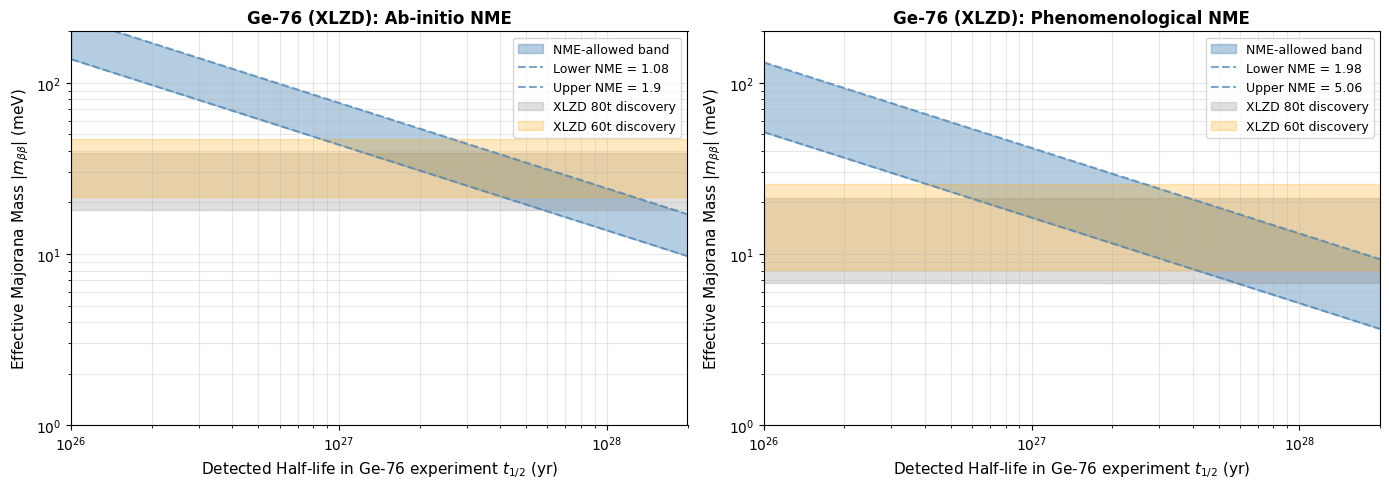

In [65]:
# Section 9: Ge $m_{\beta\beta}$ vs. Detected Half-life
# For a range of measured half-lives, show the allowed m_bb band from NME uncertainty.
# Also overlay XLZD discovery sensitivity bands (80t and 60t).

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Half-life range for x-axis (in years)
t_half_range = np.logspace(26, 30, 200)  # 10^26 to 10^30 yr



for ax, nme_band, title in [
    (axes[0], nme_ab_initio, "Ab-initio NME"),
    (axes[1], nme_pheno, "Phenomenological NME"),
]:
    # For each half-life, compute m_bb using upper and lower NME bounds
    # m_bb = sqrt(1 / (G * g_A^4 * NME^2 * t_half)) * m_e
    
    # Upper bound (from lower NME → higher m_bb)
    mbb_upper = np.sqrt(1.0 / (G * g_A**4 * nme_band["lower"]**2 * t_half_range)) * m_e
    mbb_upper_meV = mbb_upper * 1e3
    
    # Lower bound (from upper NME → lower m_bb)
    mbb_lower = np.sqrt(1.0 / (G * g_A**4 * nme_band["upper"]**2 * t_half_range)) * m_e
    mbb_lower_meV = mbb_lower * 1e3
    
    # Get the XLZD band:
    mbb_xlzd_80t_disc, mbb_xlzd_60t_disc = build_mbb_bands(nme_band, mode="discovery")
    
    # Fill between to show allowed range
    ax.fill_between(t_half_range, mbb_lower_meV, mbb_upper_meV, 
                     alpha=0.4, color="steelblue", label="NME-allowed band")
    ax.plot(t_half_range, mbb_upper_meV, color="steelblue", linewidth=1.5, 
            linestyle="--", alpha=0.7, label=f"Lower NME = {nme_band['lower']}")
    ax.plot(t_half_range, mbb_lower_meV, color="steelblue", linewidth=1.5, 
            linestyle="--", alpha=0.7, label=f"Upper NME = {nme_band['upper']}")
    
    # Add XLZD discovery sensitivity bands as horizontal rectangles
    xlzd_t_half_range_plot = [1e26, 1e30]
    
    # XLZD 80t band
    ax.fill_between(xlzd_t_half_range_plot, 
                     mbb_xlzd_80t_disc["upper"] * 1e3, 
                     mbb_xlzd_80t_disc["lower"] * 1e3,
                     alpha=0.25, color="gray", label="XLZD 80t discovery")
    
    # XLZD 60t band
    ax.fill_between(xlzd_t_half_range_plot,
                     mbb_xlzd_60t_disc["upper"] * 1e3,
                     mbb_xlzd_60t_disc["lower"] * 1e3,
                     alpha=0.25, color="orange", label="XLZD 60t discovery")
    
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"Detected Half-life in Ge-76 experiment $t_{1/2}$ (yr)", fontsize=11)
    ax.set_ylabel(r"Effective Majorana Mass $|m_{\beta\beta}|$ (meV)", fontsize=11)
    ax.set_title(f"Ge-76 (XLZD): {title}", fontsize=12, fontweight="bold")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=9, loc="upper right")
    ax.set_xlim(1e26, 2e28)
    ax.set_ylim(1, 2e2)

plt.tight_layout()
plt.show()

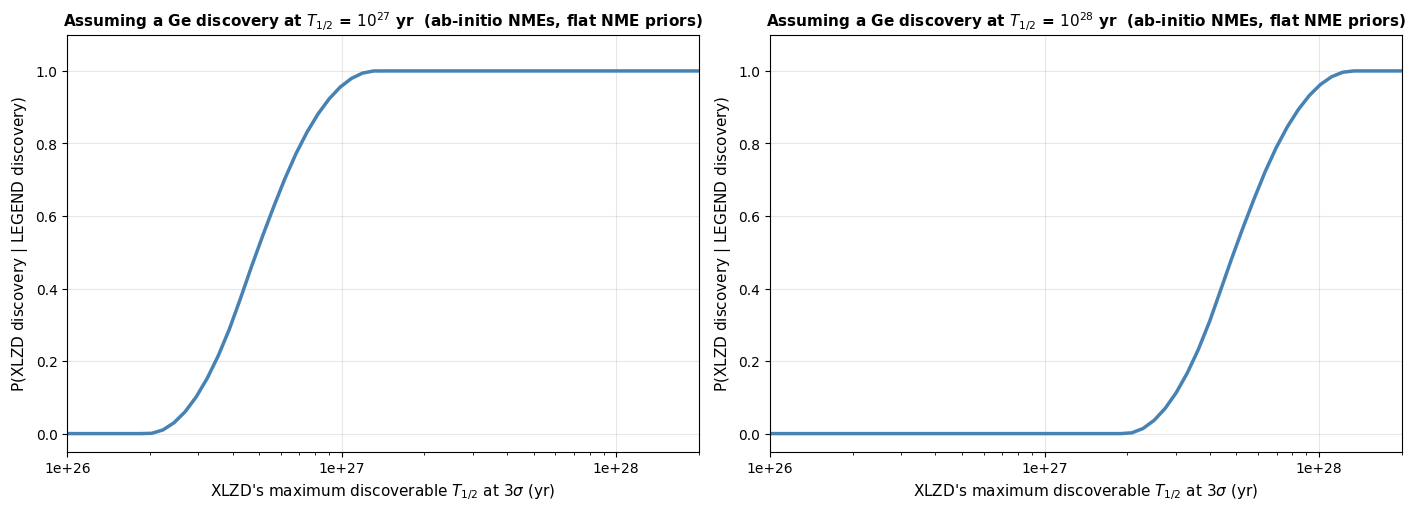

In [59]:
# P(XLZD discovery | LEGEND discovery) -- m_l-free, NME-marginalized
#
# Method:
#   1. LEGEND discovers at T_legend.  With a flat prior on Xe-136 NME in [a, b],
#      the implied m_bb is  m_bb(NME_xe) = m_e / (g_A^2 * NME_xe * sqrt(G_xe * T_legend)).
#   2. For a given m_bb, XLZD (Ge-76) detects it iff its half-life at that m_bb is
#      less than the maximum discoverable half-life T_xlzd:
#        T_ge(m_bb, NME_ge) = 1/(G_ge * g_A^4 * NME_ge^2 * (m_bb/m_e)^2) < T_xlzd
#      which requires  NME_ge > NME_ge_thresh = NME_xe * sqrt(G_xe*T_legend / G_ge*T_xlzd).
#   3. P = mean over flat Xe-NME prior of [fraction of Ge-NME range above the threshold].

legend_t_half_scenarios = [1e27, 1e28]

G_xe  = 14.58e-15   # Ge-76
G_ge  = 2.363e-15   # Xe-136

nme_xe_lo, nme_xe_hi = 2.09, 3.09   # Xe-136 ab-initio
nme_ge_lo, nme_ge_hi = 1.08, 1.90   # Ge-76 ab-initio

nme_xe_samples = np.linspace(nme_xe_lo, nme_xe_hi, 2000)
xlzd_t_half_range = np.logspace(25.5, 29.5, 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for idx, T_leg in enumerate(legend_t_half_scenarios):
    p_cond_array = []
    for T_xlzd in xlzd_t_half_range:
        # NME_ge threshold required to detect each m_bb implied by the Xe NME prior
        ratio = np.sqrt(G_ge * T_leg / (G_xe * T_xlzd))
        nme_ge_thresh = nme_xe_samples * ratio
        # Fraction of flat Ge-NME prior [nme_ge_lo, nme_ge_hi] above threshold
        frac = np.clip(
            (nme_ge_hi - nme_ge_thresh) / (nme_ge_hi - nme_ge_lo), 0.0, 1.0
        )
        # Average over flat Xe-NME prior
        p_cond_array.append(np.mean(frac))
    
    ax = axes[idx]
    ax.plot(xlzd_t_half_range, p_cond_array, color="steelblue", lw=2.5)
    ax.set_xscale("log")
    ax.set_xlabel(r"XLZD's maximum discoverable $T_{1/2}$ at 3$\sigma$ (yr)", fontsize=11)
    ax.set_ylabel(r"P(XLZD discovery $|$ LEGEND discovery)", fontsize=11)
    ax.set_title(
        f"Assuming a Ge discovery at $T_{{1/2}}$ = $10^{{{int(np.log10(T_leg))}}}$ yr  (ab-initio NMEs, flat NME priors)",
        fontsize=11, fontweight="bold"
    )
    ax.set_ylim(-0.05, 1.1)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(_fmt)
    ax.set_xlim(1e26, 2e28)

plt.show()

# Sensitivity vs. time comparison with LEGEND-1000

I'd like to plot the sensitivity of L-1000 vs. time, given an assumed background rate and the discovery potential. Then I'd like to compare this with XLZD, since I thikn XLZD will accumulate exposure faster than L-1000.

In [9]:
import numpy as np

# XLZD parameters
xlzd_abundance = 0.089


# L-1000 parameters (from pCDR)
l1000_abundance = 0.91 
l1000_mass = 1000.0 # kg
l1000_efficiency = 0.69
l1000_bkg_idx = 1e-5 # cts/keV/kg/yr
l1000_roi = 4.2 # keV (this is the 2.5keV FWHM converted into a 2sigma window)

def signal_counts(l1000_mass, l1000_efficiency, l1000_abundance, t_half, exposure_years):
    # Calculate the number of signal counts expected in LEGEND-1000
    N_A = 6.022e23  # Avogadro's number
    M_mol = 75.921  # Molar mass of Ge-76 in g/mol
    N_atoms = (l1000_mass * 1e3) * (l1000_abundance) * (N_A / M_mol)  # Number of Ge-76 atoms
    decay_rate = np.log(2) / t_half  # Decay rate in 1/yr
    counts = N_atoms * decay_rate * l1000_efficiency * exposure_years
    return counts

# Function to get half-life from a given number of signal counts and exposure
def half_life(signal_counts, l1000_mass, l1000_efficiency, l1000_abundance, exposure_years):
    # Calculate the half-life
    N_A = 6.022e23  # Avogadro's number
    M_mol = 75.921  # Molar mass of Ge-76 in g/mol
    N_atoms = (l1000_mass * 1e3) * (l1000_abundance) * (N_A / M_mol)  # Number of Ge-76 atoms
    decay_rate = signal_counts / (N_atoms * l1000_efficiency * exposure_years)
    t_half = np.log(2) / decay_rate
    return t_half


# Okay, now I need to a function to convert exposure to time
def exposure_to_time(exposure_kg_yr, l1000_mass):
    # Convert exposure in kg*yr to time in years
    return exposure_kg_yr / l1000_mass



In [10]:
l1000_bkg_rate = l1000_bkg_idx * l1000_mass * l1000_roi # cts/yr
l1000_bkg_in_10_yr = l1000_bkg_rate * 10.0 # cts in 10 years
print(f"L-1000 background rate: {l1000_bkg_rate:.3e} cts/yr")
print(f"L-1000 background in 10 years: {l1000_bkg_in_10_yr:.3f} cts")

L-1000 background rate: 4.200e-02 cts/yr
L-1000 background in 10 years: 0.420 cts


In [ ]:
# import poisson PDF and CDF from scipy.stats
from scipy.stats import poisson

# The question is, what is lambda for which the median experiment excludes 0 signal at p = 0.00135 (3sigma)



